Generate the dataset (uses `src/sample_data.py`)

**Edit `PROJECT_DIR`.**

In [19]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# ============================================================
# !important! make the `sample_data.py` file into folder `nsf-fmrg-data-challenge/src` of the original github repo.
# Then, put the direction of `nsf-fmrg-data-challenge` folder on your device below :)
# PROJECT_DIR = Path('/Users/jian/MyProjects/NSF-Future-challenge/nsf-fmrg-data-challenge')

PROJECT_DIR = Path.cwd().parent

print('PROJECT_DIR =', PROJECT_DIR)
# ============================================================

PROJECT_DIR = /Users/qalbemomina/Documents/NSF/nsf-fmrg-data-challenge


In [21]:
sys.path.append(str(PROJECT_DIR / 'src'))
from sample_data import SampleGenerator, TRACK_IDS

In [22]:
gen = SampleGenerator(PROJECT_DIR)
print('tracks:', TRACK_IDS, '| grid:', gen.frame_grid()[[0, 1, -1]], 'mm (400 frame centres)')

tracks: (8, 10, 14, 21) | grid: [20.1 20.3 99.9] mm (400 frame centres)


In [23]:
# one sample on demand (given a track and an x)
s = gen.make_sample(8, 60.1)
print({k: (v.shape if hasattr(v, 'shape') else v) for k, v in s.items()})

{'track_id': 8, 'x': 60.1, 'thermal': (5, 400, 400), 'width_mm': 1.2025640000000002, 'quality': True}


**Thermal tensors** are ~3 MB each (~5 GB for the full grid), so they are **not** shown here: fetch them lazily with
`gen.thermal_tensor(track, x)` / `gen.make_sample(...)` at train time.

## Width labels over the whole grid

`build_labels()` sweeps every frame-centre x for all tracks and returns `width_mm` + a `quality`
flag (False where x is outside a track's height coverage or an edge is clipped). 

In [24]:
labels = gen.build_labels()            # ~20 s: loads each track's raw height once
out = PROJECT_DIR / 'processed_data' / 'labels_minimal.npz'
np.savez(out, **labels)

n = labels['track_id'].size
print(f'{n} labels  ->  {out.name}')
for t in TRACK_IDS:
    m = labels['track_id'] == t
    q = labels['quality'][m]
    w = labels['width_mm'][m][q] * 1000
    print(f'  track {t:2d}: {m.sum()} rows, quality {q.mean():.0%}, '
          f'median width {np.median(w):.0f} um')

1592 labels  ->  labels_minimal.npz
  track  8: 398 rows, quality 97%, median width 1043 um
  track 10: 398 rows, quality 93%, median width 872 um
  track 14: 398 rows, quality 95%, median width 727 um
  track 21: 398 rows, quality 91%, median width 496 um


### Visualization of width

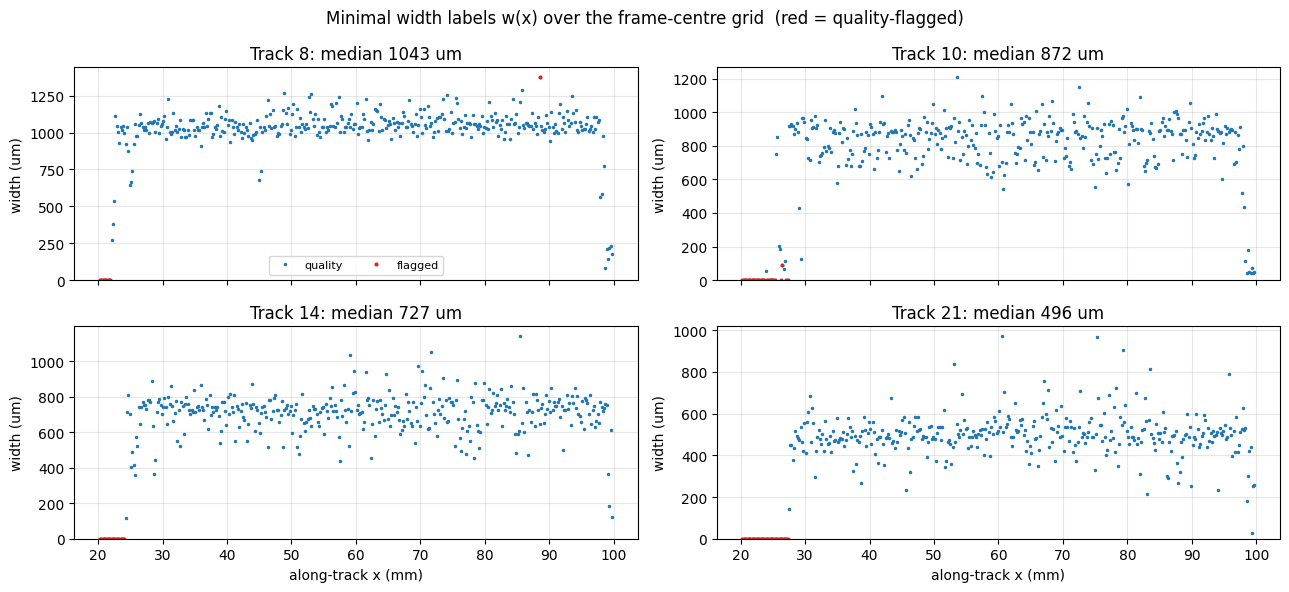

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for ax, t in zip(axes.ravel(), TRACK_IDS):
    m = labels['track_id'] == t
    x, w, q = labels['x_mm'][m], labels['width_mm'][m] * 1000, labels['quality'][m]
    ax.plot(x[q], w[q], '.', ms=3, color='tab:blue', label='quality')
    ax.plot(x[~q], w[~q], '.', ms=4, color='tab:red', label='flagged')
    ax.set_title(f'Track {t}: median {np.median(w[q]):.0f} um'); ax.set_ylim(0, None); ax.grid(alpha=0.3)
    ax.set_ylabel('width (um)')
for ax in axes[1]:
    ax.set_xlabel('along-track x (mm)')
axes[0, 0].legend(loc='lower center', fontsize=8, ncol=2)
fig.suptitle('Minimal width labels w(x) over the frame-centre grid  (red = quality-flagged)')
fig.tight_layout(); plt.show()